In [76]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

churn = pd.read_csv('churn.csv')
cohort = pd.read_csv('cohort.csv')
cus_cont = pd.read_csv('customers_contr.csv')
df = pd.read_csv('df_final.csv')

In [77]:
# Processing Categorical variables

df = pd.get_dummies(df, columns = ['IsFirstPurchase', 'TransactionType'], drop_first = False, dtype = int)
df.head(4)

,Unnamed: 0,InvoiceDate,InvoiceNo,CustomerID,StockCode,Country,Description,Quantity,Price,Revenue,DayOfWeek,Month,RevenueLag_1Day,PurchaseID,UnitPrice,AvgMonthlyProductRevenue,AvgMonthlyUnitPrice,AvgMonthlyQuantitySold,Cohort,OrderMonth,FirstPurchaseDate,UnitCost,TotalCost,GrossProfit,GrossMargin,IsFirstPurchase_False,IsFirstPurchase_True,TransactionType_Purchase,TransactionType_Refund
0,0,2011-03-17,C546889,1397100,222580,United Kingdom,FELT FARM ANIMAL RABBIT,-6,1.25,-7.50,4,3,237.89,13971-22258,0.00,9.39,0.72,7.0,2011-03,2011-03,2011-03-17,0.0,-0.0,-7.50,100.0,0,1,0,1
1,1,2011-03-17,C546889,1397100,721400,United Kingdom,BEST DAD CANDLE LETTERS,-1,0.85,-0.85,4,3,-7.50,13971-72140,0.00,1.49,0.14,-1340.0,2011-03,2011-03,2011-03-17,0.0,-0.0,-0.85,100.0,0,1,0,1
2,2,2011-03-17,C546889,1397100,227220,United Kingdom,SET OF 6 SPICE TINS PANTRY DESIGN,-1,3.95,-3.95,4,3,-0.85,13971-22722,0.00,18.53,2.46,4.0,2011-03,2011-03,2011-03-17,0.0,-0.0,-3.95,100.0,0,1,0,1
3,3,2011-03-17,546890,1339400,219850,United Kingdom,PACK OF 12 HEARTS DESIGN TISSUES,24,0.29,6.96,4,3,-3.95,13394-21985,0.01,4.36,0.13,14.0,2011-03,2011-03,2011-03-17,0.0,0.0,6.96,100.0,0,1,1,0


<Figure size 1000x500 with 0 Axes>

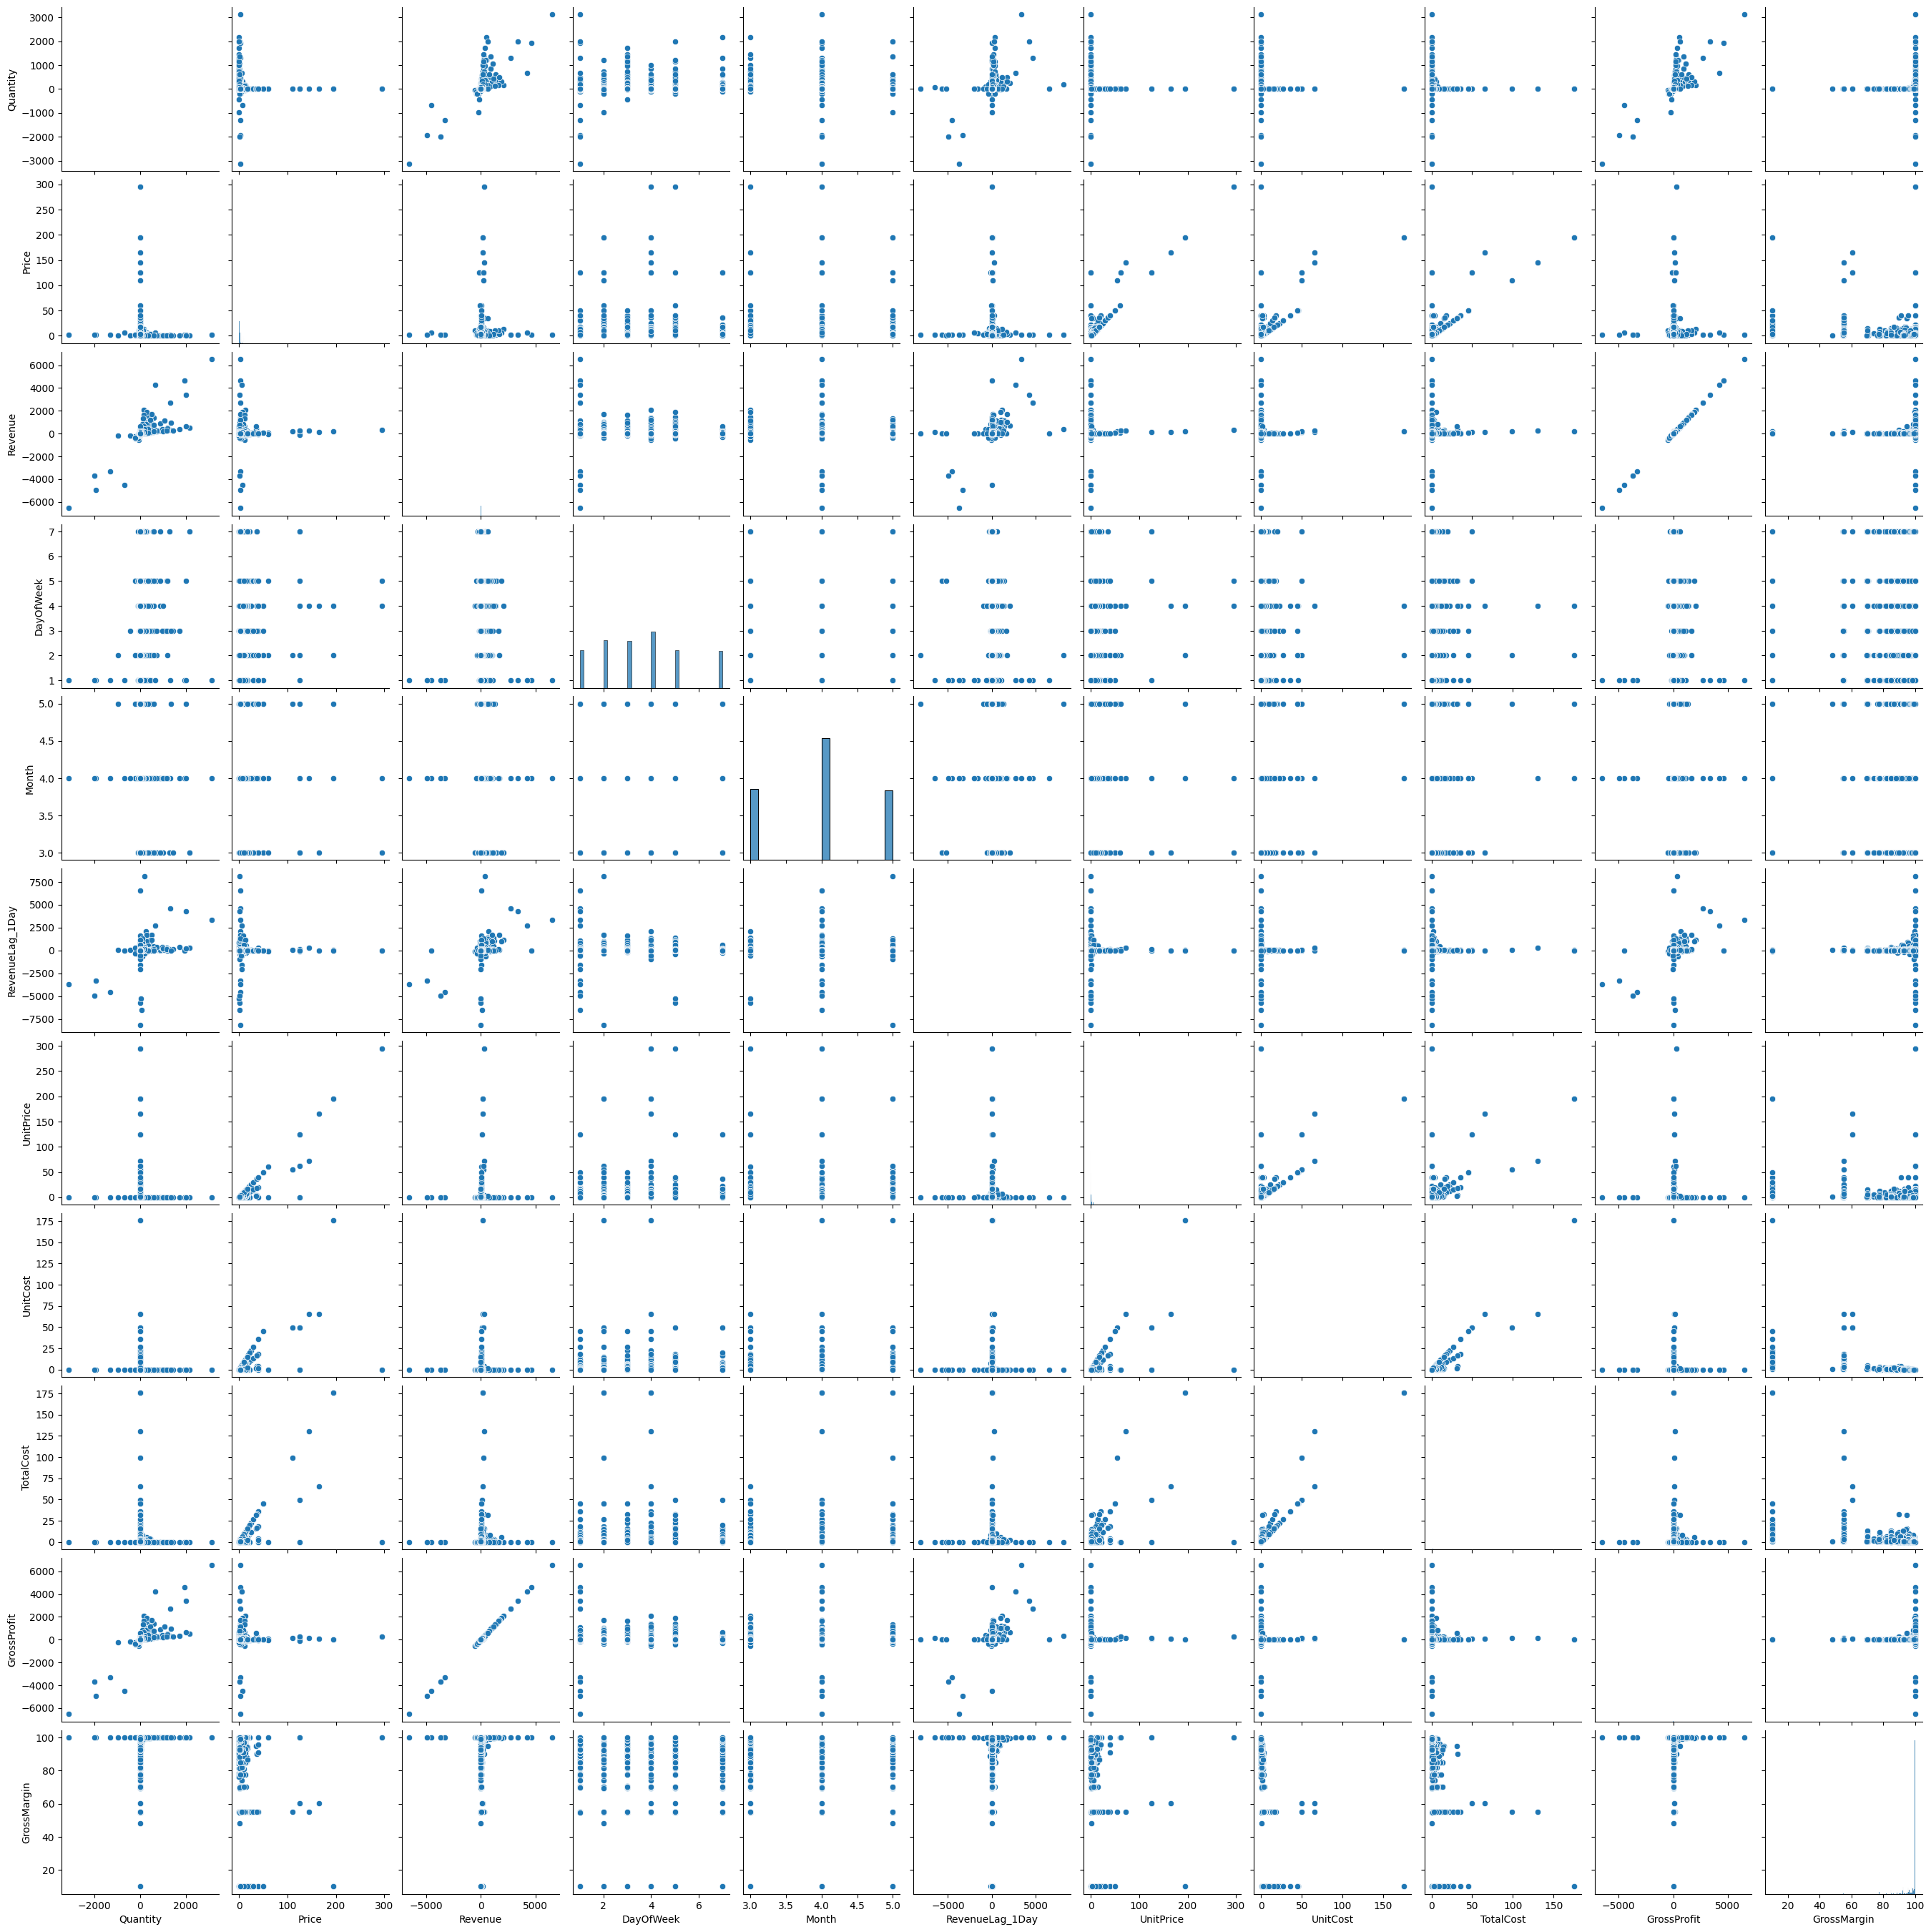

In [43]:
# Let's Remove Refunds from our Dataset-to-be

plt.figure(figsize = (10, 5))
sns.pairplot(df.select_dtypes('number').drop(columns = ['Unnamed: 0', 'AvgMonthlyProductRevenue', 'AvgMonthlyUnitPrice',
                   'AvgMonthlyQuantitySold', 'CustomerID', 'StockCode',
                   'IsFirstPurchase_False', 'IsFirstPurchase_True', 'TransactionType_Purchase',
                   'TransactionType_Refund']))
plt.show()

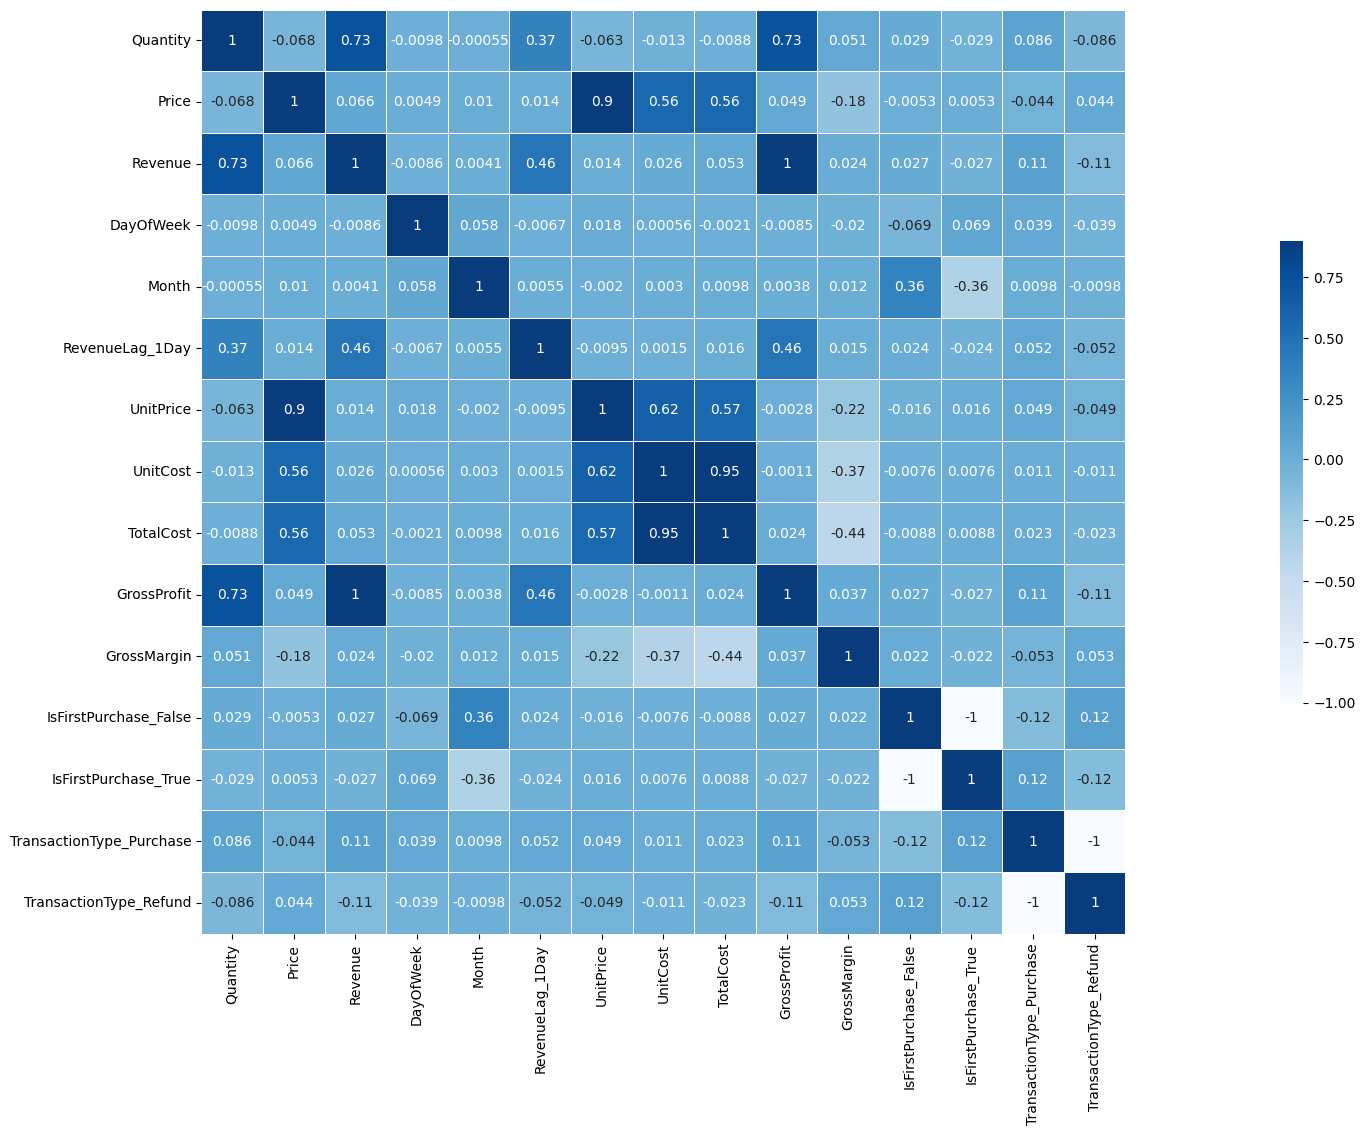

In [78]:
plt.figure(figsize = (40, 12))
sns.heatmap(df.select_dtypes('number').drop(columns = ['Unnamed: 0', 'AvgMonthlyProductRevenue', 'AvgMonthlyUnitPrice',
                   'AvgMonthlyQuantitySold', 'CustomerID', 'StockCode']).corr(),
            cmap = 'Blues', vmax = 0.9, center = 0, square = True, linewidths = 0.6,
            cbar_kws = {'shrink': 0.5}, annot = True)
plt.show()



---

## The Machine Learning **Multiple Linear Regression** Model itself:

In [90]:
# Let's Remove Unneeded Columns from our Dataset & Create our X and y Datasets

X = df[['Quantity', 'RevenueLag_1Day', 'IsFirstPurchase_False', 'IsFirstPurchase_True',
        'TransactionType_Purchase', 'TransactionType_Refund', 'GrossMargin', 'TotalCost', 'Price']]

y = df['Revenue']

In [91]:
# Splitting the Data

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.25, random_state = 7)

In [92]:
# Building & Implementing the Model

from sklearn.linear_model import LinearRegression
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler as scale
from sklearn.impute import SimpleImputer # Import SimpleImputer

model = make_pipeline(SimpleImputer(strategy = 'mean'), scale(), LinearRegression()) # Creates a Pipeline that first Imputes Missing/NaN values, then applies StandardScaler, followed by Linear Regression
model.fit(X_train, y_train)

Pipeline(steps=[('simpleimputer', SimpleImputer()),
                ('standardscaler', StandardScaler()),
                ('linearregression', LinearRegression())])

---

## XGBoost Regression Model

In [96]:
# Building & Implementing the XGBoost Model

import xgboost as xgb

# Initialize and train the XGBoost Regressor
xgb_model = xgb.XGBRegressor(objective='reg:squarederror', n_estimators=100, random_state=7)
xgb_model.fit(X_train, y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=None, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=100,
             n_jobs=None, num_parallel_tree=None, ...)

In [113]:
# Let's Inspect the Model's Results: Feature Importances

# Accessing Feature Importances (~Coefficients) from the XGBoost model
feature_importances = xgb_model.feature_importances_

# Re-creating the Column Names from the original DataFrame Selection
feature_columns = X.columns

importance_df = pd.DataFrame(feature_importances, feature_columns, columns = ['Importance'])
importance_df = importance_df.sort_values(by = 'Importance', ascending = False)

# Let's View some Core Features of the Model
display(importance_df)

,Importance
Quantity,0.698568
Price,0.280555
RevenueLag_1Day,0.013988
GrossMargin,0.004340
TotalCost,0.001877
IsFirstPurchase_False,0.000673
IsFirstPurchase_True,0.000000
TransactionType_Purchase,0.000000
TransactionType_Refund,0.000000


In [119]:
# XGBoost Model Evaluation

from sklearn.metrics import mean_absolute_error as mae, mean_squared_error as mse, root_mean_squared_error as rmse

# Make predictions on the test set
y_pred_xgb = xgb_model.predict(X_test)

# Evaluate the model
print("XGBoost R-Squared Score (%) on Training Data: {}".format(round(xgb_model.score(X_train, y_train)*100, 2)))
print("XGBoost Model Score (R-Squared) (%) on Test Data: {}".format(round(xgb_model.score(X_test, y_test)*100, 2)))
print("XGBoost Mean Absolute Error: {}".format(round(mae(y_test, y_pred_xgb), 3)))
print("XGBoost Mean Squared Error: {}".format(round(mse(y_test, y_pred_xgb), 2)))
print("XGBoost Root Mean Squared Error: {}".format(round(rmse(y_test, y_pred_xgb), 2)))

XGBoost R-Squared Score (%) on Training Data: 99.99
XGBoost Model Score (R-Squared) (%) on Test Data: 60.43
XGBoost Mean Absolute Error: 1.101
XGBoost Mean Squared Error: 1542.13
XGBoost Root Mean Squared Error: 39.27


In [105]:
# Let's View the Actual + Predicted Values side-by-side for XGBoost

df_xgb = pd.DataFrame({'Actual': y_test, 'Predicted (XGBoost)': y_pred_xgb})

display(df_xgb.head(10))

,Actual,Predicted (XGBoost)
29244,2.55,2.559670
45688,10.20,9.340176
761,2.95,3.140619
6877,2.08,2.078543
31471,17.70,17.749439
20225,20.85,20.081890
13367,19.90,19.566351
25134,204.00,242.207916
19819,15.00,14.968100
45272,1.74,1.838843


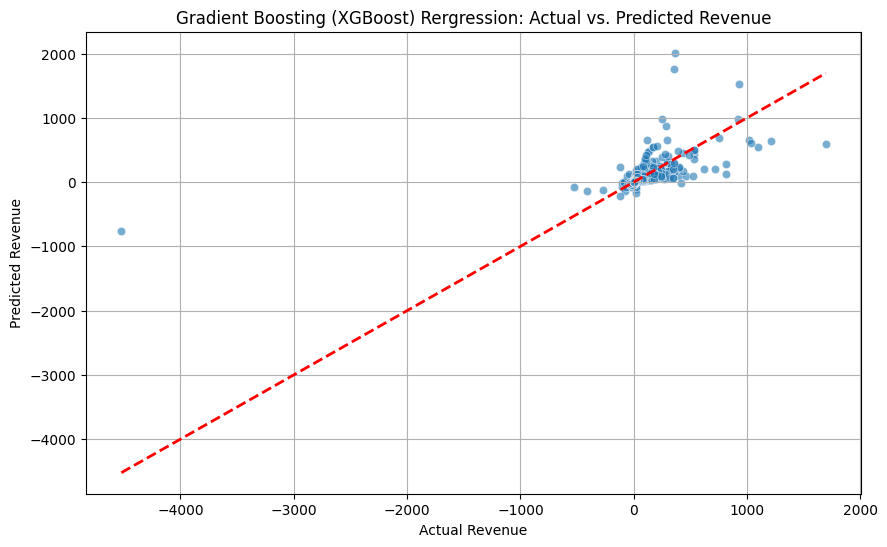

In [106]:
# Visualize Actual vs. Predicted Values with a Scatter Plot
plt.figure(figsize = (10, 6))
sns.scatterplot(x = y_test, y = y_pred, alpha = 0.6, data = df_xgb)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw = 2) # Line for Perfect Prediction
plt.xlabel('Actual Revenue')
plt.ylabel('Predicted Revenue')
plt.title("Gradient Boosting (XGBoost) Rergression: Actual vs. Predicted Revenue")
plt.grid(True)
plt.show()

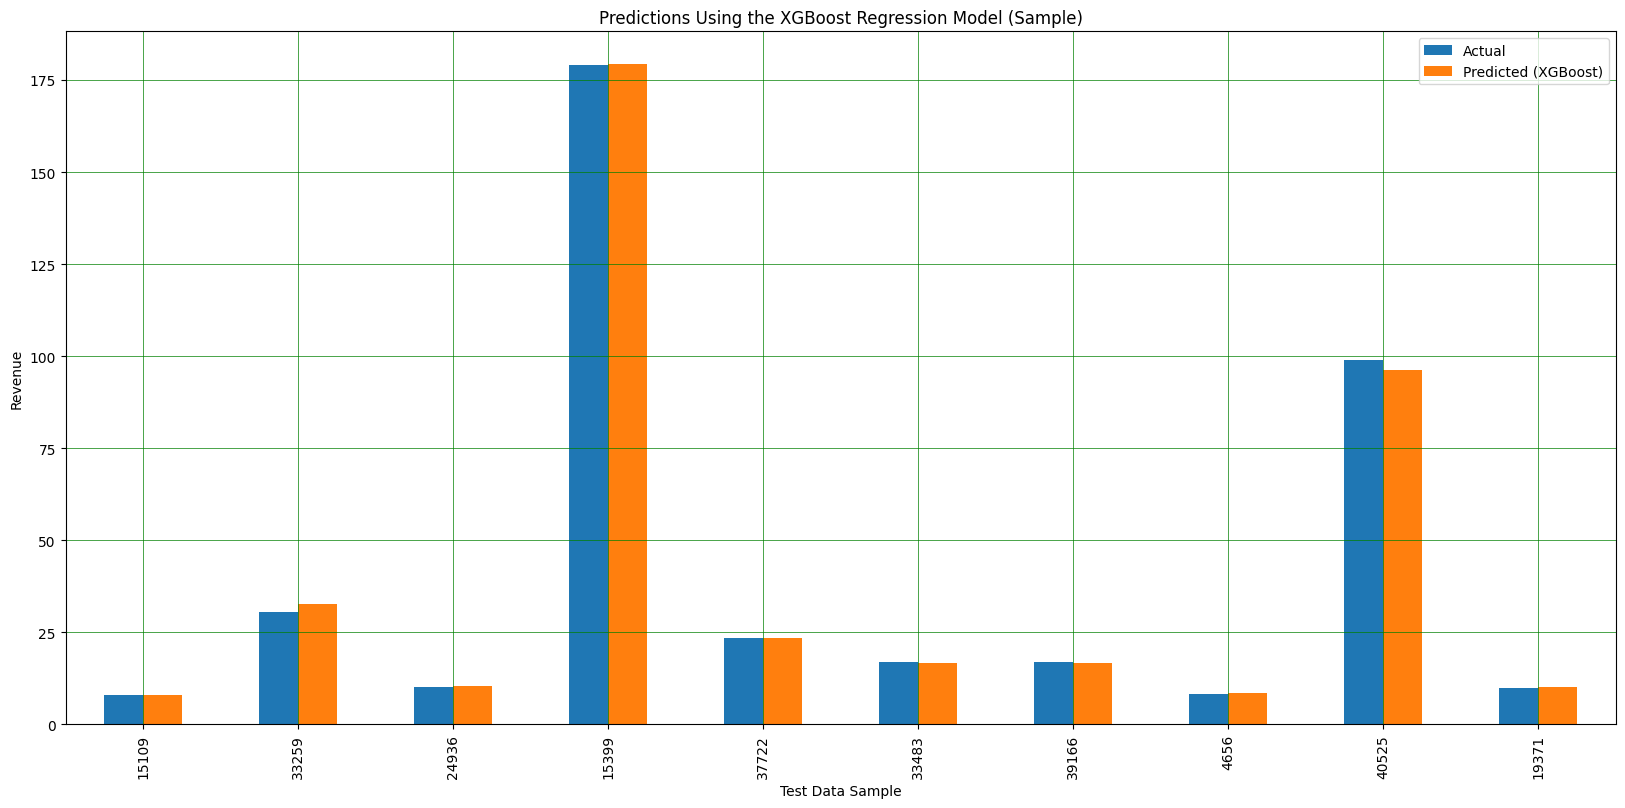

In [109]:
# Plotting a Sample of the Data for Readability

df_xgb.sample(10).plot(kind = 'bar', figsize = (20, 9))
plt.grid(which = 'major', linestyle = '-', linewidth = '0.5', color = 'green')
plt.grid(which = 'minor', linestyle = ':', linewidth = '0.5', color = 'black')
plt.xlabel('Test Data Sample')
plt.ylabel('Revenue')
plt.title('Predictions Using the XGBoost Regression Model (Sample)')
plt.show()